In [1]:
pip install kaggle


Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prince7489/gaming-hours-vs-academic-and-work-performance")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Win10\.cache\kagglehub\datasets\prince7489\gaming-hours-vs-academic-and-work-performance\versions\1


In [3]:
import pandas as pd

df = pd.read_csv("Gaming_Hours_vs_Performance_1000_Rows.csv")


#  1 Data Overview

In [4]:
df.head()


,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative
1,U0002,35,Female,Student,Sports,1.0,7.0,Night,5.4,2,7,67,72,Neutral
2,U0003,26,Male,Student,Puzzle,2.0,14.0,Morning,8.0,4,8,82,82,Positive
3,U0004,32,Male,Working Professional,Action,1.0,7.0,Night,4.9,7,7,71,66,Neutral
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 1000 non-null   object 
 1   Age                     1000 non-null   int64  
 2   Gender                  1000 non-null   object 
 3   Occupation              1000 non-null   object 
 4   Game_Type               1000 non-null   object 
 5   Daily_Gaming_Hours      1000 non-null   float64
 6   Weekly_Gaming_Hours     1000 non-null   float64
 7   Primary_Gaming_Time     1000 non-null   object 
 8   Sleep_Hours             1000 non-null   float64
 9   Stress_Level            1000 non-null   int64  
 10  Focus_Level             1000 non-null   int64  
 11  Academic_or_Work_Score  1000 non-null   int64  
 12  Productivity_Level      1000 non-null   int64  
 13  Performance_Impact      1000 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory

In [6]:
df.describe()

,Age,Daily_Gaming_Hours,Weekly_Gaming_Hours,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,26.600000,3.320300,23.242100,6.479500,5.454000,6.065000,75.07800,75.275000
std,5.207218,1.613059,11.291414,1.155848,2.281905,2.010178,11.67494,12.058805
min,18.000000,0.500000,3.500000,4.500000,2.000000,3.000000,55.00000,50.000000
25%,22.000000,2.000000,14.000000,5.475000,3.000000,4.000000,65.00000,65.000000
50%,27.000000,3.300000,23.100000,6.500000,5.000000,6.000000,75.00000,75.000000
75%,31.000000,4.800000,33.600000,7.500000,7.000000,8.000000,85.00000,86.000000
max,35.000000,6.000000,42.000000,8.500000,9.000000,9.000000,95.00000,100.000000


# 2 Check Missing Values

In [7]:

missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)


Missing values per column:
 User_ID                   0
Age                       0
Gender                    0
Occupation                0
Game_Type                 0
Daily_Gaming_Hours        0
Weekly_Gaming_Hours       0
Primary_Gaming_Time       0
Sleep_Hours               0
Stress_Level              0
Focus_Level               0
Academic_or_Work_Score    0
Productivity_Level        0
Performance_Impact        0
dtype: int64


# 3  Data Cleaning & clean csv

In [8]:
import pandas as pd

# Load original CSV
df = pd.read_csv("Gaming_Hours_vs_Performance_1000_Rows.csv")

# Make a copy to avoid warnings
df = df.copy()

# Rename columns: lowercase + underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Handle missing numeric values
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Handle missing categorical values
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop any unnecessary columns if exist (example placeholder)
# df.drop(columns=['unnecessary_column'], inplace=True)

# Save clean CSV
clean_csv_path = "cleaned_gaming_data.csv"
df.to_csv(clean_csv_path, index=False)

print(f"Clean CSV saved at: {clean_csv_path}")


Clean CSV saved at: cleaned_gaming_data.csv


# 4 Load Clean CSV & Derived Columns / Analysis

In [9]:
# Load clean CSV
df_clean = pd.read_csv("cleaned_gaming_data.csv")

# Derived Columns
df_clean = df_clean.copy()
df_clean = df_clean.assign(
    total_gaming_hours = df_clean['daily_gaming_hours'] * 7,
    performance_ratio = df_clean['academic_or_work_score'] / (df_clean['weekly_gaming_hours'] + 1)
)

df_clean.head()


,user_id,age,gender,occupation,game_type,daily_gaming_hours,weekly_gaming_hours,primary_gaming_time,sleep_hours,stress_level,focus_level,academic_or_work_score,productivity_level,performance_impact,total_gaming_hours,performance_ratio
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative,28.0,2.379310
1,U0002,35,Female,Student,Sports,1.0,7.0,Night,5.4,2,7,67,72,Neutral,7.0,8.375000
2,U0003,26,Male,Student,Puzzle,2.0,14.0,Morning,8.0,4,8,82,82,Positive,14.0,5.466667
3,U0004,32,Male,Working Professional,Action,1.0,7.0,Night,4.9,7,7,71,66,Neutral,7.0,8.875000
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral,14.7,4.267516


# 5 Analysis Operations (5+) on Clean Data

In [10]:
# Load clean CSV
import pandas as pd
df = pd.read_csv("cleaned_gaming_data.csv")

# Make a copy
df = df.copy()

# Derived Columns (if not already added)
df = df.assign(
    total_gaming_hours = df['daily_gaming_hours'] * 7,
    performance_ratio = df['academic_or_work_score'] / (df['weekly_gaming_hours'] + 1)
)

# ----- Analysis Operations -----

# 1. Average daily gaming hours
avg_daily_gaming = df['daily_gaming_hours'].mean()
print("Average Daily Gaming Hours:", round(avg_daily_gaming,2))



# 2. Average academic/work score
avg_score = df['academic_or_work_score'].mean()
print("Average Academic/Work Score:", round(avg_score,2))



# 3. Correlation: weekly gaming vs academic/work score
corr = df['weekly_gaming_hours'].corr(df['academic_or_work_score'])
print("Correlation (Weekly Gaming vs Score):", round(corr,2))



# 4. Top 5 users by performance ratio
top5_perf = df.nlargest(5, 'performance_ratio')
print("Top 5 Users by Performance Ratio:\n", top5_perf[['user_id','performance_ratio']])

# 5. Average sleep hours grouped by primary gaming time
avg_sleep = df.groupby('primary_gaming_time')['sleep_hours'].mean()
print("Average Sleep Hours by Primary Gaming Time:\n", avg_sleep)


Average Daily Gaming Hours: 3.32
Average Academic/Work Score: 75.08
Correlation (Weekly Gaming vs Score): -0.01
Top 5 Users by Performance Ratio:
     user_id  performance_ratio
603   U0604          20.444444
378   U0379          20.000000
725   U0726          18.888889
914   U0915          18.888889
270   U0271          18.666667
Average Sleep Hours by Primary Gaming Time:
 primary_gaming_time
Evening    6.522485
Morning    6.462757
Night      6.452025
Name: sleep_hours, dtype: float64


# 6 Visualizations on Clean Data

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

## I. Distribution of daily gaming hour

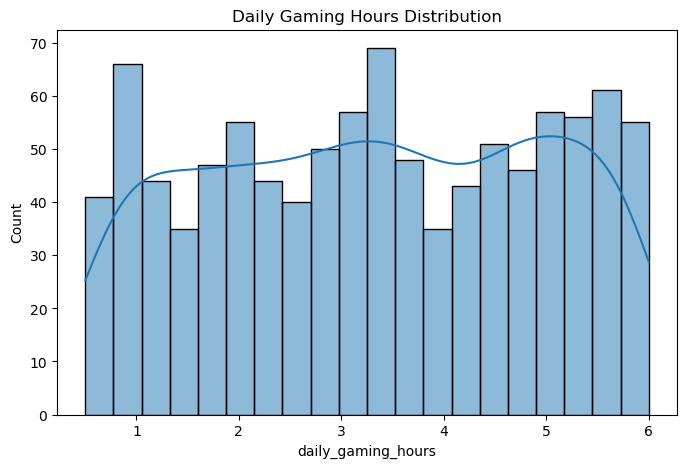

In [12]:
# 1. Distribution of daily gaming hours
plt.figure(figsize=(8,5))
sns.histplot(df['daily_gaming_hours'], bins=20, kde=True)
plt.title("Daily Gaming Hours Distribution")
plt.show()


## II. Scatter: Weekly gaming hours vs Academic/Work score

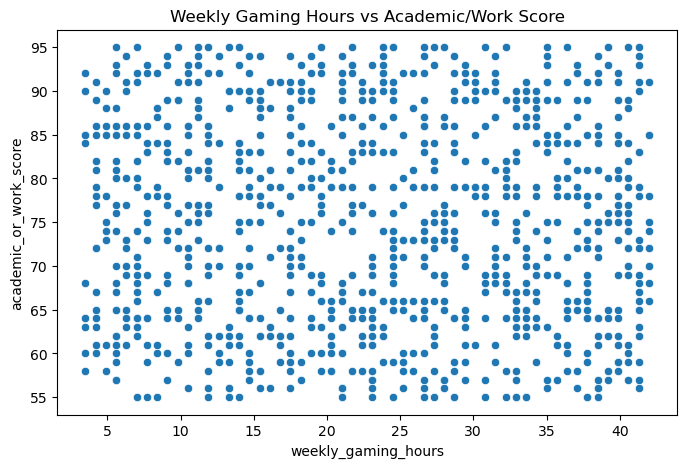

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='weekly_gaming_hours', y='academic_or_work_score', data=df)
plt.title("Weekly Gaming Hours vs Academic/Work Score")
plt.show()


## III. Performance Ratio distribution

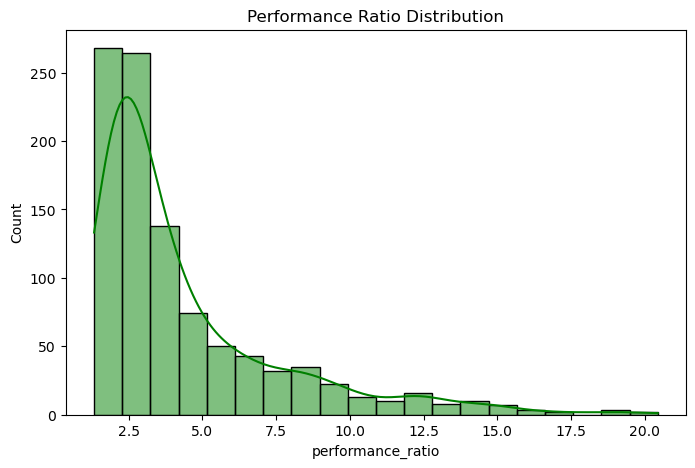

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['performance_ratio'], bins=20, kde=True, color='green')
plt.title("Performance Ratio Distribution")
plt.show()

 ##  IV. Sleep hours vs primary gaming time

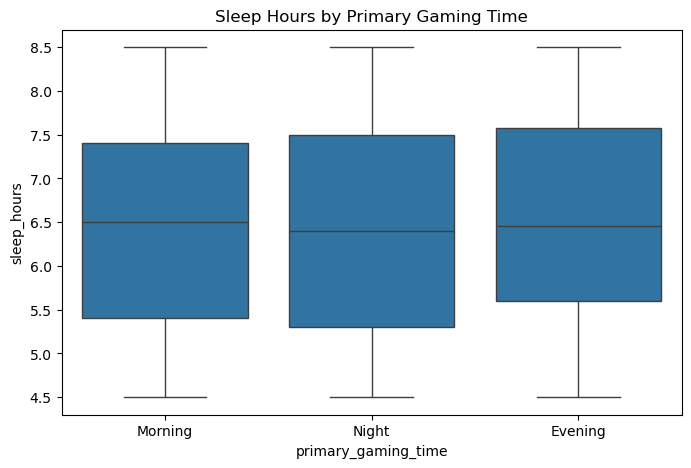

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='primary_gaming_time', y='sleep_hours', data=df)
plt.title("Sleep Hours by Primary Gaming Time")
plt.show()


## V. Stress level vs focus level

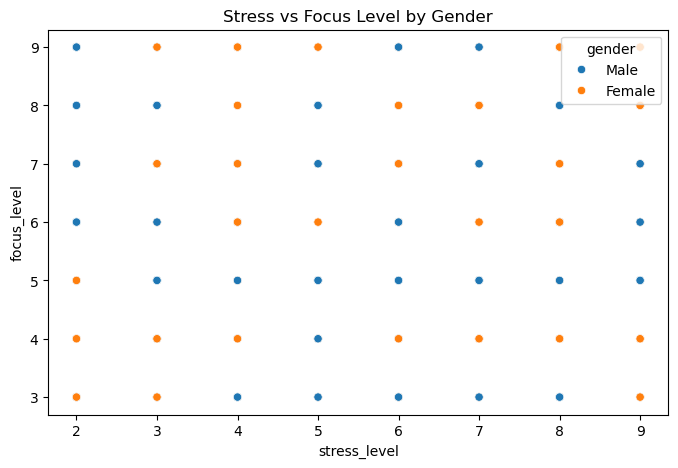

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='stress_level', y='focus_level', data=df, hue='gender')
plt.title("Stress vs Focus Level by Gender")
plt.show()


In [17]:
# 7 SQL via PyODBC

In [18]:
import pyodbc
import sqlalchemy as sal


In [19]:
import pyodbc

# Connection string using your server & database
conn_str = (
    r"DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=DESKTOP-3QNPVC1;"
    r"DATABASE=GamingPerformanceDB;"
    r"Trusted_Connection=yes;"
)

try:
    # Connect to SQL Server
    conn = pyodbc.connect(conn_str)
    cursor = conn.cursor()
    print(" Connected to GamingPerformanceDB successfully!")
except Exception as e:
    print(" Connection failed:", e)


 Connected to GamingPerformanceDB successfully!


In [20]:
cursor.execute("SELECT DB_NAME()")
print("Current Database:", cursor.fetchone()[0])


Current Database: GamingPerformanceDB


In [21]:
# Ensure column names are snake_case
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)


Index(['user_id', 'age', 'gender', 'occupation', 'game_type',
       'daily_gaming_hours', 'weekly_gaming_hours', 'primary_gaming_time',
       'sleep_hours', 'stress_level', 'focus_level', 'academic_or_work_score',
       'productivity_level', 'performance_impact', 'total_gaming_hours',
       'performance_ratio'],
      dtype='object')


In [24]:
# Assuming 'df' is your cleaned CSV DataFrame and connection is active
# Make sure user_id is string
df['user_id'] = df['user_id'].astype(str)

for index, row in df.iterrows():
    cursor.execute("""
        INSERT INTO gaming_performance (
            user_id, age, gender, occupation, game_type, daily_gaming_hours, weekly_gaming_hours,
            primary_gaming_time, sleep_hours, stress_level, focus_level, academic_or_work_score,
            productivity_level, performance_impact
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """,
    row.user_id, row.age, row.gender, row.occupation, row.game_type,
    row.daily_gaming_hours, row.weekly_gaming_hours, row.primary_gaming_time,
    row.sleep_hours, row.stress_level, row.focus_level, row.academic_or_work_score,
    row.productivity_level, row.performance_impact
    )

# Commit changes
conn.commit()
print(" Cleaned CSV data inserted successfully into SQL Server!")


 Cleaned CSV data inserted successfully into SQL Server!


In [23]:
df['user_id'] = df['user_id'].str.extract('(\d+)').astype(int)

In [25]:
import pandas as pd

df_sql = pd.read_sql("SELECT TOP 5 * FROM gaming_performance", conn)
print(df_sql)


  user_id  age  gender            occupation game_type  daily_gaming_hours  \
0       1   20    Male               Student       FPS                 3.5   
1       1   21    Male  Working Professional    Action                 4.0   
2       2   35  Female               Student    Sports                 1.0   
3       3   26    Male               Student    Puzzle                 2.0   
4       4   32    Male  Working Professional    Action                 1.0   

   weekly_gaming_hours primary_gaming_time  sleep_hours  stress_level  \
0                 24.5             Evening          6.5           4.0   
1                 28.0             Morning          4.6           6.0   
2                  7.0               Night          5.4           2.0   
3                 14.0             Morning          8.0           4.0   
4                  7.0               Night          4.9           7.0   

   focus_level  academic_or_work_score  productivity_level performance_impact  
0          8

C:\Users\Win10\AppData\Local\Temp\ipykernel_5984\2083060193.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql("SELECT TOP 5 * FROM gaming_performance", conn)
